# GeoLifestyle Recommender v1

This notebook scores and ranks cities based on:
- Region (East / South / West / Midwest)
- Budget (monthly housing budget)
- Climate (Cold / Mild / Warm / Hot)
- Pace of life (Slow / Balanced / Fast)
- Culture & diversity importance (Low / Medium / High)

It outputs a ranked list of cities with a breakdown of how each city matches the preferences.

In [1]:
# Basic setup: install and import key libraries
!pip install pandas numpy scikit-learn matplotlib seaborn joblib --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
data = pd.DataFrame({
    'temperature': [70, 65, 80, 75, 90],
    'cost_index': [2000, 1800, 2200, 2100, 2500],
    'crime_rate': [3.5, 2.9, 4.0, 3.2, 4.5]
})
data.head()


,temperature,cost_index,crime_rate
0,70,2000,3.5
1,65,1800,2.9
2,80,2200,4.0
3,75,2100,3.2
4,90,2500,4.5


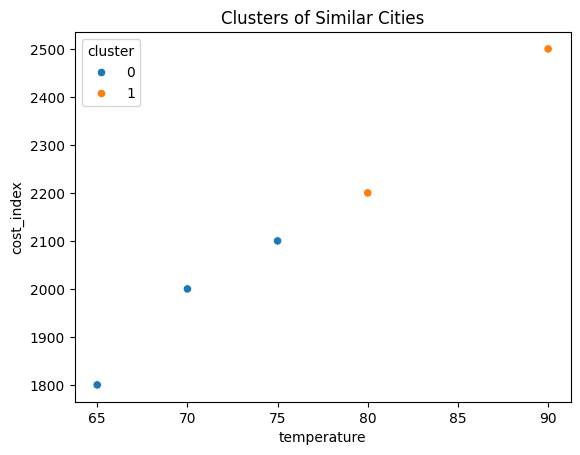

In [3]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(data)

kmeans = KMeans(n_clusters=2, random_state=42)
data['cluster'] = kmeans.fit_predict(scaled)

sns.scatterplot(data=data, x='temperature', y='cost_index', hue='cluster', palette='tab10')
plt.title('Clusters of Similar Cities')
plt.show()


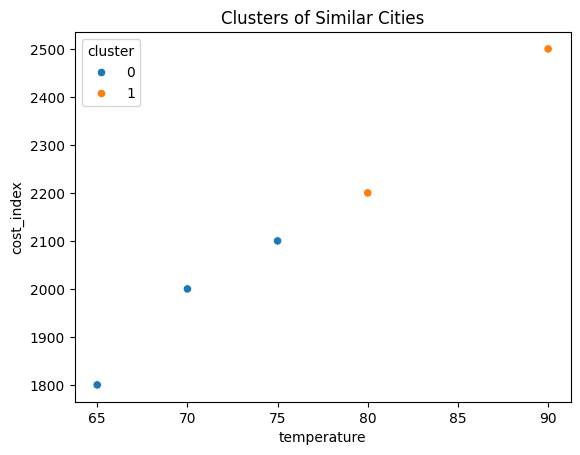

In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(data)

kmeans = KMeans(n_clusters=2, random_state=42)
data['cluster'] = kmeans.fit_predict(scaled)

sns.scatterplot(data=data, x='temperature', y='cost_index', hue='cluster', palette='tab10')
plt.title('Clusters of Similar Cities')
plt.show()


In [5]:
import joblib
joblib.dump(kmeans, 'geo_model.pkl')


['geo_model.pkl']

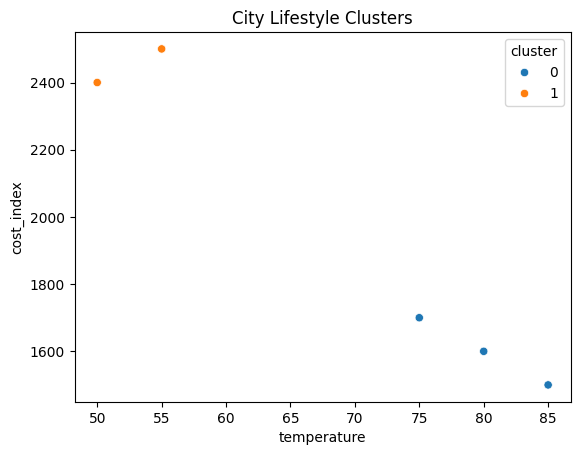

,city,temperature,cost_index,crime_rate,cluster
0,Atlanta,75,1700,3.2,0
1,Houston,80,1600,4.0,0
2,Boston,55,2500,2.5,1
3,Phoenix,85,1500,4.5,0
4,Seattle,50,2400,2.9,1


In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Example starter data
data = pd.DataFrame({
    'city': ['Atlanta', 'Houston', 'Boston', 'Phoenix', 'Seattle'],
    'temperature': [75, 80, 55, 85, 50],
    'cost_index': [1700, 1600, 2500, 1500, 2400],
    'crime_rate': [3.2, 4.0, 2.5, 4.5, 2.9]
})

features = data[['temperature', 'cost_index', 'crime_rate']]
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=2, random_state=42)
data['cluster'] = kmeans.fit_predict(scaled)

sns.scatterplot(
    data=data,
    x='temperature',
    y='cost_index',
    hue='cluster',
    palette='tab10'
)
plt.title('City Lifestyle Clusters')
plt.show()

data


In [2]:
import joblib
import numpy as np

model = kmeans  # we just trained it

def predict_city(temperature, cost_index, crime_rate):
    features = np.array([[temperature, cost_index, crime_rate]])
    cluster = model.predict(features)
    return cluster


In [1]:
import pandas as pd

# Tiny starter dataset – you can expand this later or move to CSV
cities = pd.DataFrame([
    {
        "city": "Atlanta, GA",
        "region": "South",
        "avg_rent": 1900,        # average 1BR rent
        "climate": "Warm",
        "pace": "Balanced",      # Chill / Balanced / Fast
        "culture": "High"        # Low / Medium / High
    },
    {
        "city": "Houston, TX",
        "region": "South",
        "avg_rent": 1700,
        "climate": "Hot",
        "pace": "Balanced",
        "culture": "High"
    },
    {
        "city": "Miami, FL",
        "region": "South",
        "avg_rent": 2300,
        "climate": "Warm",
        "pace": "Fast",
        "culture": "High"
    },
    {
        "city": "Raleigh, NC",
        "region": "East",
        "avg_rent": 1600,
        "climate": "Mild",
        "pace": "Chill",
        "culture": "Medium"
    },
    {
        "city": "New York, NY",
        "region": "East",
        "avg_rent": 2800,
        "climate": "Cold",
        "pace": "Fast",
        "culture": "High"
    },
    {
        "city": "Charleston, SC",
        "region": "South",
        "avg_rent": 1800,
        "climate": "Mild",
        "pace": "Chill",
        "culture": "Medium"
    },
])

cities


,city,region,avg_rent,climate,pace,culture
0,"Atlanta, GA",South,1900,Warm,Balanced,High
1,"Houston, TX",South,1700,Hot,Balanced,High
2,"Miami, FL",South,2300,Warm,Fast,High
3,"Raleigh, NC",East,1600,Mild,Chill,Medium
4,"New York, NY",East,2800,Cold,Fast,High
5,"Charleston, SC",South,1800,Mild,Chill,Medium


In [2]:
# This is the structure of the questions your model cares about
# For now, we hard-code YOUR preferences (later you'll turn this into UI / frontend inputs)

user_prefs = {
    "regions": ["East", "South"],     # 1) East/South/West/Midwest/etc.
    "budget_min": 1500,               # 2) Min monthly rent
    "budget_max": 2500,               # 3) Max monthly rent
    "climate": ["Mild", "Warm"],      # 4) Preferred climate range
    "pace": "Balanced",               # 5) Chill / Balanced / Fast
    "culture": "High",                # Preference for culture/diversity
}
user_prefs


{'regions': ['East', 'South'],
 'budget_min': 1500,
 'budget_max': 2500,
 'climate': ['Mild', 'Warm'],
 'pace': 'Balanced',
 'culture': 'High'}

In [3]:
def score_city(row, prefs):
    score = 0
    details = {}

    # 1) Region match
    if row["region"] in prefs["regions"]:
        score += 20
        details["region"] = 20
    else:
        details["region"] = 0

    # 2) Budget (penalize if outside range)
    rent = row["avg_rent"]
    if prefs["budget_min"] <= rent <= prefs["budget_max"]:
        score += 30
        details["budget"] = 30
    else:
        # simple penalty: farther away = less score
        gap = min(abs(rent - prefs["budget_min"]), abs(rent - prefs["budget_max"]))
        penalty = min(30, gap / 50)   # tweakable
        budget_score = max(0, 30 - penalty)
        score += budget_score
        details["budget"] = budget_score

    # 3) Climate
    if row["climate"] in prefs["climate"]:
        score += 20
        details["climate"] = 20
    else:
        details["climate"] = 0

    # 4) Pace
    if row["pace"] == prefs["pace"]:
        score += 15
        details["pace"] = 15
    else:
        details["pace"] = 0

    # 5) Culture/diversity
    # treat "High" as best, "Medium" okay, "Low" meh
    pref = prefs["culture"]
    city_culture = row["culture"]

    culture_score_map = {
        ("High", "High"): 15,
        ("High", "Medium"): 10,
        ("High", "Low"): 5,
        ("Medium", "High"): 10,
        ("Medium", "Medium"): 12,
        ("Medium", "Low"): 5,
    }
    culture_score = culture_score_map.get((pref, city_culture), 5)
    score += culture_score
    details["culture"] = culture_score

    return score, details


In [4]:
scores = []
breakdowns = []

for _, row in cities.iterrows():
    s, detail = score_city(row, user_prefs)
    scores.append(s)
    breakdowns.append(detail)

cities["score"] = scores
cities["score_details"] = breakdowns

# Sort by score descending
ranked = cities.sort_values(by="score", ascending=False)
ranked[["city", "region", "avg_rent", "climate", "pace", "culture", "score"]]


,city,region,avg_rent,climate,pace,culture,score
0,"Atlanta, GA",South,1900,Warm,Balanced,High,100.0
2,"Miami, FL",South,2300,Warm,Fast,High,85.0
1,"Houston, TX",South,1700,Hot,Balanced,High,80.0
3,"Raleigh, NC",East,1600,Mild,Chill,Medium,80.0
5,"Charleston, SC",South,1800,Mild,Chill,Medium,80.0
4,"New York, NY",East,2800,Cold,Fast,High,59.0


In [5]:
for _, row in ranked.head(3).iterrows():
    print("City:", row["city"])
    print("Total score:", row["score"])
    print("Breakdown:", row["score_details"])
    print("-" * 40)


City: Atlanta, GA
Total score: 100.0
Breakdown: {'region': 20, 'budget': 30, 'climate': 20, 'pace': 15, 'culture': 15}
----------------------------------------
City: Miami, FL
Total score: 85.0
Breakdown: {'region': 20, 'budget': 30, 'climate': 20, 'pace': 0, 'culture': 15}
----------------------------------------
City: Houston, TX
Total score: 80.0
Breakdown: {'region': 20, 'budget': 30, 'climate': 0, 'pace': 15, 'culture': 15}
----------------------------------------


In [6]:
def get_user_preferences():
    print("Enter your preferences:")
    region = input("Region (East/South/West/Midwest): ")
    budget_min = int(input("Minimum budget: "))
    budget_max = int(input("Maximum budget: "))
    climate = input("Preferred climate (Cold/Mild/Warm/Hot): ")
    pace = input("Preferred pace (Slow/Balanced/Fast): ")
    culture = input("Culture importance (Low/Medium/High): ")

    return {
        "region": region,
        "budget_min": budget_min,
        "budget_max": budget_max,
        "climate": climate,
        "pace": pace,
        "culture": culture
    }


In [7]:
prefs = get_user_preferences()


Enter your preferences:


Region (East/South/West/Midwest):  east
Minimum budget:  20000
Maximum budget:  200000
Preferred climate (Cold/Mild/Warm/Hot):  hot
Preferred pace (Slow/Balanced/Fast):  fast
Culture importance (Low/Medium/High):  medium-high


In [8]:
def filter_cities(df, prefs):
    df = df[df['budget'] >= prefs['budget_min']]
    df = df[df['budget'] <= prefs['budget_max']]
    df = df[df['region'].str.contains(prefs['region'], case=False)]
    return df


In [10]:
import pandas as pd

cities_df = pd.DataFrame([
    {
        "city": "Atlanta, GA",
        "region": "South",
        "budget": 1800,
        "climate": "Warm",
        "pace": "Medium",
        "culture": "High"
    },
    {
        "city": "Miami, FL",
        "region": "South",
        "budget": 2200,
        "climate": "Hot",
        "pace": "Fast",
        "culture": "Medium-High"
    },
    {
        "city": "Houston, TX",
        "region": "South",
        "budget": 1800,
        "climate": "Hot",
        "pace": "Medium",
        "culture": "High"
    },
    {
        "city": "Los Angeles, CA",
        "region": "West",
        "budget": 2800,
        "climate": "Mild",
        "pace": "Fast",
        "culture": "High"
    },
    {
        "city": "New York, NY",
        "region": "East",
        "budget": 2800,
        "climate": "Cold",
        "pace": "Fast",
        "culture": "High"
    },
    {
        "city": "Charleston, SC",
        "region": "South",
        "budget": 1800,
        "climate": "Mild",
        "pace": "Chill",
        "culture": "Medium"
    }
])

cities_df


,city,region,budget,climate,pace,culture
0,"Atlanta, GA",South,1800,Warm,Medium,High
1,"Miami, FL",South,2200,Hot,Fast,Medium-High
2,"Houston, TX",South,1800,Hot,Medium,High
3,"Los Angeles, CA",West,2800,Mild,Fast,High
4,"New York, NY",East,2800,Cold,Fast,High
5,"Charleston, SC",South,1800,Mild,Chill,Medium


In [11]:
filtered = filter_cities(cities_df, prefs)
filtered.head()


,city,region,budget,climate,pace,culture


import pandas as pd
import numpy as np

# --------------------
# 1. Base city dataset
# --------------------
cities_df = pd.DataFrame([
    {"city": "Atlanta, GA",   "region": "South", "budget": 1800, "climate": "Warm", "pace": "Balanced", "culture": "High"},
    {"city": "Miami, FL",     "region": "South", "budget": 2200, "climate": "Hot",  "pace": "Fast",     "culture": "High"},
    {"city": "Houston, TX",   "region": "South", "budget": 1700, "climate": "Warm", "pace": "Balanced", "culture": "Medium"},
    {"city": "Charlotte, NC", "region": "South", "budget": 1600, "climate": "Mild", "pace": "Balanced", "culture": "Medium"},
    {"city": "New York, NY",  "region": "East",  "budget": 2800, "climate": "Cold", "pace": "Fast",     "culture": "High"},
    {"city": "DC, DC",        "region": "East",  "budget": 2600, "climate": "Cold", "pace": "Fast",     "culture": "High"},
    {"city": "Chicago, IL",   "region": "Midwest","budget": 2000,"climate": "Cold", "pace": "Balanced", "culture": "Medium"},
    {"city": "LA, CA",        "region": "West",  "budget": 2600, "climate": "Warm", "pace": "Fast",     "culture": "High"},
])

cities_df


In [14]:
# --------------------
# 2. Preference config
# --------------------
prefs = {
    "region": ["East", "South"],   # preferred regions
    "budget_min": 1500,
    "budget_max": 2500,
    "climate": ["Mild", "Warm"],
    "pace": ["Balanced", "Fast"],
    "culture_importance": "High",  # how much to weigh culture
}
prefs


{'region': ['East', 'South'],
 'budget_min': 1500,
 'budget_max': 2500,
 'climate': ['Mild', 'Warm'],
 'pace': ['Balanced', 'Fast'],
 'culture_importance': 'High'}

In [15]:
# --------------------
# 3. Filter step
# --------------------
def filter_cities(df: pd.DataFrame, prefs: dict) -> pd.DataFrame:
    filtered = df.copy()
    filtered = filtered[filtered["budget"].between(prefs["budget_min"], prefs["budget_max"])]
    filtered = filtered[filtered["region"].isin(prefs["region"])]
    filtered = filtered[filtered["climate"].isin(prefs["climate"])]
    filtered = filtered[filtered["pace"].isin(prefs["pace"])]
    return filtered.reset_index(drop=True)

filtered = filter_cities(cities_df, prefs)
filtered


,city,region,budget,climate,pace,culture
